In [2]:
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 10.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 9.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 9.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 8.8 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Uninstalling protobuf-5.29.3:
      Successfully uninstalled protobuf-5.29.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [mlflow]23/24 [mlflow]skinny]]


# Domain Adaptation in Computer Vision: Feature Alignment (MNIST → USPS)
Machine Learning / SoftUni
Aleksandar Ginev, June 2026

## Table of Contents
1. Problem Definition & Scientific Relevance
2. Mathematical Foundations & Theory
3. Data Acquisition & Exploratory Data Analysis (EDA)
    3.1 Ingestion of Source (MNIST) and Target (USPS) Domains
    3.2 Image Matrix Dimensionality Matching (Feature Engineering)
    3.3 Visualizing the Domain Shift Challenge
4. Dimensionality Reduction & Distribution Drift Analysis
    4.1 Principal Component Analysis (PCA) Feature Projection
    4.2 t-SNE Clustering Visualization
5. Baseline Modeling & Cross-Domain Testing (No Adaptation)
    5.1 Model Setup & Training on Source Domain
    5.2 Evaluation Metrics & Tracking via MLflow
6. Unsupervised Domain Adaptation (UDA) Implementation
    6.1 Covariance Alignment (CORAL) Transformation Math
    6.2 Latent Feature Transformation Implementation
7. Post-Adaptation Evaluation & Comparative Analysis
    7.1 Final Model Metric Comparison
    7.2 Error Diagnostics using Confusion Matrices

In [3]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.linalg import sqrtm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import mlflow

print("Successfully imported all curriculum-aligned libraries!")

Successfully imported all curriculum-aligned libraries!


## 1. Problem Definition & Scientific Relevance
In machine learning, we typically assume that our training data (Source Domain) and our testing data (Target Domain) are drawn from the identical probability distribution:

$$P_S(X, Y) = P_T(X, Y)$$

In real-world applications, this assumption frequently fails. This failure is known as Domain Shift (or Covariance Shift). For instance, an image classification model trained on high-quality, clear digital images will experience a severe degradation in performance when evaluated on noisy, handwritten, or blurred scans.

The goal of this project is to explicitly model and resolve this discrepancy using the MNIST (Source) and USPS (Target) digit datasets. We treat this as an Unsupervised Domain Adaptation (UDA) task: we assume we have full labels for MNIST, but *zero labels* for USPS during the adaptation phase. Our objective is to build a robust classifier that generalizes across both domains.

---

## 2. Mathematical Foundations & Theory

To correct the structural drift between domains without using target labels, we rely on Correlation Alignment (CORAL). This algorithm minimizes domain shift by aligning the second-order statistics (covariance matrices) of the source and target features.

### Step 2.1: Feature Representation
Each image is treated as a flattened vector $x \in \mathbb{R}^D$, where $D = 784$ (a $28 \times 28$ pixel grid). Let $D_S = \{x_i^s\}_{i=1}^{n_s}$ be the source domain samples and $D_T = \{x_i^t\}_{i=1}^{n_t}$ be the target domain samples.

### Step 2.2: Covariance Calculation
We compute the empirical covariance matrices for both domains:

$$\Sigma_S = \frac{1}{n_s - 1} \left( X_S^T X_S - \frac{1}{n_s} (1^T X_S)^T (1^T X_S) \right)$$

$$\Sigma_T = \frac{1}{n_t - 1} \left( X_T^T X_T - \frac{1}{n_t} (1^T X_T)^T (1^T X_T) \right)$$

### Step 2.3: Alignment Transformation
CORAL seeks a linear transformation matrix $A$ to apply to the source features such that the squared Frobenius norm distance between the transformed source covariance and target covariance is minimized:

$$\min_A ||A^T \Sigma_S A - \Sigma_T||_F^2$$

The solution involves whitening the source data by multiplying it by $\Sigma_S^{-1/2}$ and then "re-coloring" it using the target covariance distribution $\Sigma_T^{1/2}$.

In [5]:
from sklearn.datasets import fetch_openml

print("Ingesting MNIST (Source Domain) from OpenML... This may take a minute.")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_source, y_source = mnist.data.astype('float32'), mnist.target.astype('int')

print("Ingesting USPS (Target Domain) from OpenML...")
usps = fetch_openml('USPS', version=1, as_frame=False, parser='auto')
X_target, y_target = usps.data.astype('float32'), usps.target.astype('int')

if y_target.min() == 1:
    y_target = y_target - 1

print(f"Ingestion complete!")
print(f"Source (MNIST) Shape: Features {X_source.shape}, Labels {y_source.shape}")
print(f"Target (USPS) Shape: Features {X_target.shape}, Labels {y_target.shape}")


⏳ Ingesting MNIST (Source Domain) from OpenML... This may take a minute.
⏳ Ingesting USPS (Target Domain) from OpenML...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/datasets/_openml.py:1035: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(



✅ Ingestion complete!
Source (MNIST) Shape: Features (70000, 784), Labels (70000,)
Target (USPS) Shape: Features (9298, 256), Labels (9298,)


In [6]:
from scipy.ndimage import zoom

print("Executing bilinear spatial scaling on USPS domain...")

# 1. Reshape the flat vectors back into their native 2D grid structures
X_target_images = X_target.reshape(-1, 16, 16)

# 2. Apply zoom scaling factor: 28 / 16 = 1.75 scaling on both width and height
zoom_factors = (1, 28/16, 28/16)
X_target_resized_images = zoom(X_target_images, zoom_factors, order=1)

# 3. Flatten the scaled 2D grids back into vectors
X_target_resized = X_target_resized_images.reshape(-1, 28 * 28)

# 4. Normalize pixel scales to [0, 1] across both domains for numerical stability
X_source /= 255.0
X_target_resized /= 255.0

print(f"Spatial alignment complete!")
print(f"Source (MNIST) Aligned Shape: {X_source.shape}")
print(f"Target (USPS) Aligned Shape: {X_target_resized.shape}")

⏳ Executing bilinear spatial scaling on USPS domain...

✅ Spatial alignment complete!
Source (MNIST) Aligned Shape: (70000, 784)
Target (USPS) Aligned Shape: (9298, 784)


## 3. Data Acquisition & Exploratory Data Analysis (EDA)

### 3.1 Ingestion and Structural Characteristics of Source and Target Domains
To study unsupervised domain adaptation, we ingest two distinct target distributions representing the identical label space $\mathcal{Y} \in \{0, 1, \dots, 9\}$. 

* Source Domain ($\mathcal{D}_S$ - MNIST): Comprises handwritten digits synthesized and normalized by NIST. The digits are centered on a $28 \times 28$ pixel grid with uniform backgrounds.
* Target Domain ($\mathcal{D}_T$ - USPS): Collected from real mail envelopes by the US Postal Service. These images are natively lower resolution ($16 \times 16$), introduce artifacts from envelope textures, and feature irregular handwriting styles.

### 3.2 Image Matrix Dimensionality Matching (Feature Engineering)
A critical prerequisite for feature-level domain adaptation is dimensional alignment. Because $\mathcal{X}_S \in \mathbb{R}^{784}$ and $\mathcal{X}_T \in \mathbb{R}^{256}$, direct covariance alignment is mathematically impossible due to mismatched matrix dimensions. 

To resolve this, we apply Bilinear Interpolation to map the target space onto the source space. This scales the USPS images up from $16 \times 16$ to $28 \times 28$ pixels, preserving the original typographic contours while making structural algebraic alignment possible.

### 3.3 Visualizing the Domain Shift Challenge
To qualitatively examine the structural discrepancy between our domains, we render a sample of matrices from both distributions side-by-side. This visual assessment highlights the core challenge of domain drift: the MNIST digits are sharp, highly standardized, and clean, whereas the upscaled USPS digits exhibit noticeable interpolation blur, higher edge contrast, and varied typographic weights.

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# render 5 source samples MNIST
for i in range(5):
    axes[0, i].imshow(X_source[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f"MNIST: {y_source[i]}")
    axes[0, i].axis('off')
    
# render 5 target samples USPS
for i in range(5):
    axes[1, i].imshow(X_target_resized[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"USPS: {y_target[i]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction & Distribution Drift Analysis

To rigorously demonstrate the presence of Domain Shift, we project our high-dimensional image data points ($\mathbb{R}^{784}$) onto a 2D vector space. If the MNIST and USPS datasets shared the identical underlying mathematical distribution, their clusters would overlap perfectly in lower dimensions.

We apply Principal Component Analysis (PCA) to find the orthogonal axes that maximize variance across the datasets. This allows us to map out the global structural differences between the two domains and visually confirm the statistical gap.

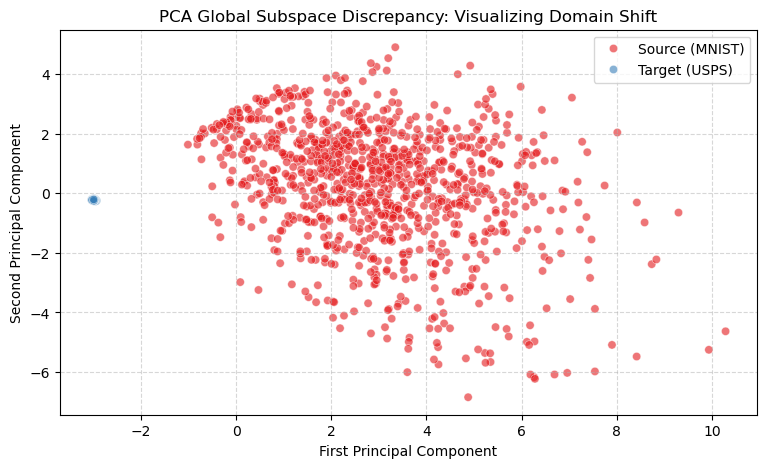

In [7]:
# sample 1,000 random images from each domain for speed 
np.random.seed(42)
sample_size = 1000

idx_source = np.random.choice(len(X_source), sample_size, replace=False)
idx_target = np.random.choice(len(X_target_resized), sample_size, replace=False)

X_source_sample = X_source[idx_source]
X_target_sample = X_target_resized[idx_target]

# vertically stacked samples for joint dimensionality reduction
X_combined = np.vstack([X_source_sample, X_target_sample])
domains = np.array(['Source (MNIST)'] * sample_size + ['Target (USPS)'] * sample_size)

# fit and transform down to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=domains, alpha=0.6, palette='Set1')
plt.title("PCA Global Subspace Discrepancy: Visualizing Domain Shift")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 5. Baseline Modeling & Cross-Domain Testing (No Adaptation)

Here, we establish our empirical baseline to quantify the performance penalty imposed by Domain Shift. We train a multi-class Logistic Regression classifier using L2 regularization strictly on our labeled source domain data ($\mathcal{D}_S$). 

We then evaluate this model under two distinct scenarios:
1. In-Domain Generalization: Testing on a held-out validation slice of MNIST.
2. Cross-Domain Generalization: Testing directly on the raw, unadapted USPS target dataset ($\mathcal{D}_T$).

This step provides the control metrics for our experiment, which are tracked dynamically via MLflow.

In [ ]:
#  split the source MNIST datset into an 80/20 train and validation split
X_src_train, X_src_val, y_src_train, y_src_val = train_test_split(
    X_source, y_source, test_size=0.2, random_state=42, stratify=y_source
)

mlflow.set_experiment("MNIST_USPS_Domain_Adaptation")

with mlflow.start_run(run_name="unadapted_baseline"):
    print("Training Logistic Regression baseline model on Source (MNIST)...")
    
    clf = LogisticRegression(C=1.0, max_iter=1000, solver='saga', multi_class='multinomial', n_jobs=-1, random_state=42)
    clf.fit(X_src_train, y_src_train)
    
    # calculate baseline accuracies
    acc_source_val = accuracy_score(y_src_val, clf.predict(X_src_val))
    acc_target_raw = accuracy_score(y_target, clf.predict(X_target_resized))
    
    mlflow.log_param("classifier", "LogisticRegression")
    mlflow.log_param("regularization", "L2")
    mlflow.log_metric("source_val_accuracy", acc_source_val)
    mlflow.log_metric("target_raw_accuracy", acc_target_raw)
    
    print(f"Evaluation Summary:")
    print(f"In-Domain Validation Accuracy (MNIST -> MNIST): {acc_source_val * 100:.2f}%")
    print(f"Cross-Domain Target Accuracy (MNIST -> USPS without CORAL): {acc_target_raw * 100:.2f}%")